# PL3 — Building a GPT from Scratch
### Generative AI · MSc in Artificial Intelligence · Lab 3

You will build a GPT-style language model from its parts and train it on the Shakespeare corpus of PL2.

| Part | Topic | Suggested time |
|---|---|---|
| 1 | Scaled dot-product attention and the causal mask | 25 min |
| 2 | Multi-head attention and the Transformer block | 30 min |
| 3 | Position: permutation and RoPE | 20 min |
| 4 | Train a character-level GPT | 35 min |
| 5 | Attention maps and the KV cache (**homework**) | 60 min |

**Instructions.** Fill every cell marked `# TODO` and every *Your answer* cell. Cells starting with `# CHECK` test your implementation: they must pass silently. Answers should be short (2–5 sentences) and cite your own numbers.

**Names / student numbers:** _…_

## 0. Setup
On **Google Colab**, choose *Runtime → Change runtime type → GPU* and upload the `data/` folder. Locally, any recent PyTorch (≥ 2.1) works on CPU; training in Part 4 then takes about 5–10 minutes.

In [1]:
import math, time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.11.0+cu130 | device: cuda


---
## Part 1 — Scaled dot-product attention

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Shapes: `q` is `(..., T_q, d)`, `k` is `(..., T_k, d)`, `v` is `(..., T_k, d_v)`. The leading `...` dimensions (batch, heads) must broadcast, so write the function once and it will work for multi-head attention in Part 2.

### Exercise 1.1 — The attention function
`mask` is an optional boolean tensor of shape `(T_q, T_k)` where `True` means *may attend*. Masked scores must become `-inf` before the softmax. Return both the output and the attention weights.

In [2]:
def attention(q, k, v, mask=None):
    d = q.size(-1)
    scores = q @ k.transpose(-2, -1) / math.sqrt(d)
    if mask is not None:
        scores = scores.masked_fill(~mask, float('-inf'))
    weights = F.softmax(scores, dim=-1)
    out = weights @ v
    return out, weights


In [3]:
# CHECK 1.1 — the worked example of lecture T2 (slide 12), then a random comparison with PyTorch
K = torch.tensor([[1., 0.], [0., 1.], [.5, .5]])
V = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
q = torch.tensor([[0., 3.]])
out, w = attention(q, K, V)
assert torch.allclose(w, torch.tensor([[0.082, 0.682, 0.236]]), atol=1e-3), w
assert torch.allclose(out, torch.tensor([[0.318, 0.918]]), atol=1e-3), out

qr, kr, vr = torch.randn(2, 3, 5, 8), torch.randn(2, 3, 7, 8), torch.randn(2, 3, 7, 4)
assert torch.allclose(attention(qr, kr, vr)[0], F.scaled_dot_product_attention(qr, kr, vr), atol=1e-5)
print("1.1 OK  weights of ' sat':", w.numpy().round(3))

1.1 OK  weights of ' sat': [[0.082 0.682 0.236]]


### Exercise 1.2 — The causal mask
Implement `causal_mask(T_q, T_k)`. When `T_q == T_k` it is the usual lower-triangular matrix. When the queries are the **last** `T_q` positions of a sequence of length `T_k` (this happens with the KV cache in Part 5), query `i` may attend to keys `0 … T_k − T_q + i`. Hint: `torch.tril(..., diagonal=...)`.

In [4]:
def causal_mask(T_q, T_k=None):
    T_k = T_q if T_k is None else T_k
    i = torch.arange(T_q)[:, None]
    j = torch.arange(T_k)[None, :]
    return j <= i + (T_k - T_q)


In [5]:
# CHECK 1.2
assert causal_mask(3).tolist() == [[True, False, False], [True, True, False], [True, True, True]]
assert causal_mask(1, 4).tolist() == [[True, True, True, True]]           # last query sees everything
assert causal_mask(2, 4).tolist() == [[True, True, True, False], [True, True, True, True]]

x = torch.randn(1, 6, 8)
out1, w1 = attention(x, x, x, causal_mask(6))
assert torch.allclose(w1.sum(-1), torch.ones(1, 6)) and torch.all(w1.triu(1) == 0)
x2 = x.clone(); x2[:, 4:] = torch.randn(1, 2, 8)                            # change the future only
out2, _ = attention(x2, x2, x2, causal_mask(6))
assert torch.allclose(out1[:, :4], out2[:, :4]), "earlier positions must not see later ones"
print("1.2 OK")

1.2 OK


### Exercise 1.3 — Why divide by √dₖ?
For $d_k \in \{4, 16, 64, 256, 1024\}$ draw 1 000 queries and 128 keys with i.i.d. $\mathcal N(0,1)$ entries. For each $d_k$ measure:

* the standard deviation of the raw scores $q\cdot k$;
* the mean **entropy** (in nats) of the attention distribution over the 128 keys, with and without dividing by $\sqrt{d_k}$.

The maximum possible entropy is $\ln 128 \approx 4.85$ (uniform attention); 0 means one-hot.

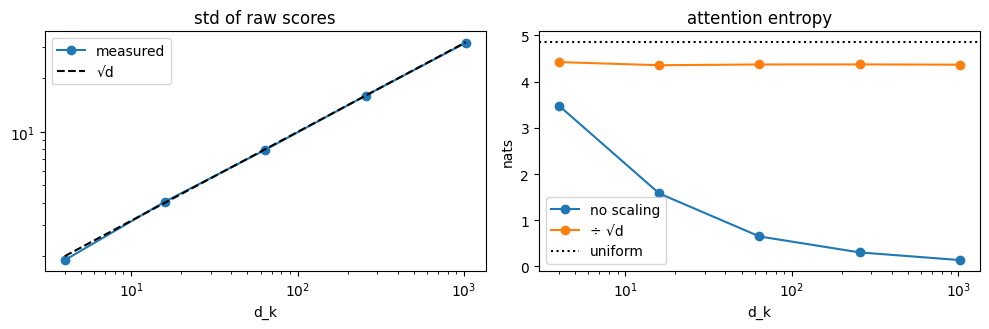

d=    4  std=  1.90  entropy raw=3.48  scaled=4.42
d=   16  std=  4.05  entropy raw=1.58  scaled=4.35
d=   64  std=  7.94  entropy raw=0.65  scaled=4.37
d=  256  std= 16.01  entropy raw=0.30  scaled=4.37
d= 1024  std= 31.79  entropy raw=0.14  scaled=4.37


In [6]:
dims = [4, 16, 64, 256, 1024]
score_std, ent_raw, ent_scaled = [], [], []

def mean_entropy(scores):
    p = scores.softmax(-1)
    return float(-(p * torch.log(p + 1e-12)).sum(-1).mean())

for d in dims:
    q = torch.randn(1000, d)
    k = torch.randn(128, d)
    s = q @ k.T
    score_std.append(float(s.std()))
    ent_raw.append(mean_entropy(s))
    ent_scaled.append(mean_entropy(s / math.sqrt(d)))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(dims, score_std, "o-", label="measured"); ax[0].plot(dims, [math.sqrt(d) for d in dims], "k--", label="√d")
ax[0].set(xscale="log", yscale="log", xlabel="d_k", title="std of raw scores"); ax[0].legend()
ax[1].plot(dims, ent_raw, "o-", label="no scaling"); ax[1].plot(dims, ent_scaled, "o-", label="÷ √d")
ax[1].axhline(math.log(128), color="k", ls=":", label="uniform"); ax[1].set(xscale="log", xlabel="d_k", ylabel="nats", title="attention entropy"); ax[1].legend()
plt.tight_layout(); plt.show()
for d, s_, a, b in zip(dims, score_std, ent_raw, ent_scaled):
    print(f"d={d:5d}  std={s_:6.2f}  entropy raw={a:.2f}  scaled={b:.2f}")


In [7]:
# CHECK 1.3
assert all(abs(s_ / math.sqrt(d) - 1) < 0.1 for s_, d in zip(score_std, dims))
assert ent_raw[-1] < 0.5 and all(abs(e - ent_scaled[0]) < 0.3 for e in ent_scaled)
print("1.3 OK")

1.3 OK


**Q1.3.** Descreva os dois gráficos. Porque é que uma entropia próxima de zero é um problema *para o treino*, e não apenas para a interpretação?

**Your answer:**

O desvio-padrão dos scores aumenta aproximadamente como √dₖ. Sem a divisão por √dₖ, a entropia diminui rapidamente e, para dimensões grandes, aproxima-se de zero: a atenção fica demasiado concentrada numa posição. Isto é um problema durante o treino porque os gradientes tornam-se pouco informativos e o modelo perde a capacidade de distribuir a atenção por várias posições; a divisão por √dₖ mantém a distribuição numa escala mais estável.


---
## Part 2 — Multi-head attention and the Transformer block

We now build the model of lecture T2, slide 24: a decoder-only, **pre-norm** Transformer with RMSNorm, a GELU feed-forward network, learned position embeddings and weight tying. Linear layers have **no bias**, as in most modern LLMs.

Every attention layer returns its keys and values (`present`) and accepts cached ones (`past_kv`). You do not need them until Part 5; the code handling them is given.

### Exercise 2.1 — Multi-head attention

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, causal=True):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads, self.head_dim, self.causal = n_heads, d_model // n_heads, causal
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        self.last_weights = None

    def forward(self, x, past_kv=None):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        if past_kv is not None:
            k = torch.cat([past_kv[0], k], dim=2)
            v = torch.cat([past_kv[1], v], dim=2)
        present = (k, v)
        mask = causal_mask(T, k.size(2)).to(x.device) if self.causal else None
        out, weights = attention(q, k, v, mask)
        self.last_weights = weights.detach()
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(out), present


In [9]:
# CHECK 2.1
torch.manual_seed(0)
mha = MultiHeadAttention(64, 8)
x = torch.randn(2, 10, 64)
y, (k_, v_) = mha(x)
assert y.shape == (2, 10, 64) and k_.shape == (2, 8, 10, 8)
assert sum(p.numel() for p in mha.parameters()) == 4 * 64 * 64            # 4 d²

one = MultiHeadAttention(16, 1)                                             # one head = plain attention
xq = torch.randn(1, 5, 16)
Wq, Wk, Wv = one.qkv.weight.split(16, dim=0)
ref, _ = attention(xq @ Wq.T, xq @ Wk.T, xq @ Wv.T, causal_mask(5))
assert torch.allclose(one(xq)[0], ref @ one.proj.weight.T, atol=1e-5)

x2 = x.clone(); x2[:, 7:] = torch.randn(2, 3, 64)
assert torch.allclose(mha(x)[0][:, :7], mha(x2)[0][:, :7], atol=1e-5)       # still causal
print("2.1 OK")

2.1 OK


### Exercise 2.2 — RMSNorm, feed-forward, block
* `RMSNorm(x) = x / sqrt(mean(x²) + eps) · γ`, with γ a learned vector initialised to ones.
* `FeedForward`: `d → 4d → d`, GELU in between, no biases.
* `Block` (pre-norm): `x = x + attn(norm1(x))`, then `x = x + ffn(norm2(x))`. It returns `(x, present)`.

In [10]:
class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.eps, self.weight = eps, nn.Parameter(torch.ones(d))

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight


class FeedForward(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 4 * d, bias=False),
            nn.GELU(),
            nn.Linear(4 * d, d, bias=False),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, d, n_heads):
        super().__init__()
        self.norm1, self.attn = RMSNorm(d), MultiHeadAttention(d, n_heads)
        self.norm2, self.ffn = RMSNorm(d), FeedForward(d)

    def forward(self, x, past_kv=None):
        a, present = self.attn(self.norm1(x), past_kv)
        x = x + a
        x = x + self.ffn(self.norm2(x))
        return x, present


In [11]:
# CHECK 2.2
xn = torch.randn(3, 5, 32) * 7 + 2
out = RMSNorm(32)(xn)
assert torch.allclose(out.pow(2).mean(-1), torch.ones(3, 5), atol=1e-4)
assert torch.allclose(RMSNorm(2)(torch.tensor([[3., 4.]])), torch.tensor([[0.8485, 1.1314]]), atol=1e-3)   # lecture example
blk = Block(32, 4)
assert blk(xn)[0].shape == xn.shape
assert sum(p.numel() for p in blk.parameters()) == 12 * 32 * 32 + 2 * 32     # 12 d² + two norms
print("2.2 OK")

2.2 OK


### Exercise 2.3 — The GPT
Complete `forward`: token embeddings + position embeddings (positions start at `pos_offset`), the blocks (collect each block's `present`), final norm, output head, and the cross-entropy loss if `targets` is given. The output head shares its weight with the token embedding (weight tying).

In [12]:
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, context):
        super().__init__()
        self.context = context
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(context, d_model)
        self.blocks = nn.ModuleList([Block(d_model, n_heads) for _ in range(n_layers)])
        self.norm_f = RMSNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Embedding)):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None, past=None, pos_offset=0):
        B, T = idx.shape
        assert pos_offset + T <= self.context, "sequence longer than the context window"
        past = past or [None] * len(self.blocks)
        positions = torch.arange(pos_offset, pos_offset + T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(positions)[None, :, :]
        presents = []
        for block, past_kv in zip(self.blocks, past):
            x, present = block(x, past_kv)
            presents.append(present)
        x = self.norm_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss, presents


In [13]:
# CHECK 2.3 — GPT-2 small shape, built on the "meta" device so no memory is allocated
with torch.device("meta"):
    gpt2 = GPT(vocab_size=50257, d_model=768, n_layers=12, n_heads=12, context=1024)
n_params = sum(p.numel() for p in gpt2.parameters())
print(f"GPT-2 small shape: {n_params:,} parameters")
assert abs(n_params - 124.3e6) / 124.3e6 < 0.002
tiny = GPT(65, 32, 2, 4, 16)
logits, loss, presents = tiny(torch.randint(0, 65, (2, 16)), torch.randint(0, 65, (2, 16)))
assert logits.shape == (2, 16, 65) and len(presents) == 2 and abs(loss.item() - math.log(65)) < 0.3
print("2.3 OK — initial loss", round(loss.item(), 3), "vs ln(65) =", round(math.log(65), 3))

GPT-2 small shape: 124,337,664 parameters
2.3 OK — initial loss 4.166 vs ln(65) = 4.174


**Q2.3.** (a) Escreva a contagem de parâmetros como uma fórmula em $d$, $L$, $V$ e no comprimento do contexto, e compare-a com o número apresentado acima. (b) Porque é que a loss inicial deve estar próxima de $\ln V$? O que suspeitaria se fosse 80?

**Your answer:**

Com $d$ dimensão do modelo, $L$ camadas, $V$ tokens e contexto $C$, e com *weight tying*, o número de parâmetros é aproximadamente $Vd + Cd + L(12d^2 + 2d) + d$. Para GPT-2 small ($d=768$, $L=12$, $V=50257$, $C=1024$), isto dá cerca de 124,4 milhões de parâmetros, consistente com os 124,3 milhões apresentados pelo notebook. No início, as probabilidades estão aproximadamente uniformes, por isso a cross-entropy esperada é $\ln V$. Se a loss inicial fosse 80, suspeitaria de um erro na implementação, nos targets, nas dimensões ou de logits com escala anormalmente elevada.


---
## Part 3 — Position

### Exercise 3.1 — Attention is permutation-equivariant
For a **non-causal** attention layer, show numerically that permuting the input tokens permutes the output in the same way: `mha(x[:, perm]) == mha(x)[:, perm]`. Then repeat with a **causal** layer.

In [ ]:
torch.manual_seed(0)
x = torch.randn(1, 6, 32)
perm = torch.tensor([3, 0, 5, 1, 4, 2])
# TODO: build MultiHeadAttention(32, 4, causal=False) and (…, causal=True); compare f(x[:, perm]) with f(x)[:, perm]
raise NotImplementedError("TODO")
print("non-causal equivariant:", equiv_full, "| causal equivariant:", equiv_causal)

In [ ]:
# CHECK 3.1
assert equiv_full and not equiv_causal
print("3.1 OK")

**Q3.1.** Explain both results. A decoder-only model with a causal mask and *no* position embeddings can still learn something about position. How?

**Your answer:**

_…_

### Exercise 3.2 — Rotary position embeddings (RoPE)
Split the last dimension into pairs $(x_{2i}, x_{2i+1})$ and rotate pair $i$ at position $m$ by the angle $m\,\theta_i$, with $\theta_i = \text{base}^{-2i/d}$:

$$\begin{pmatrix} x'_{2i} \\ x'_{2i+1}\end{pmatrix} = \begin{pmatrix} \cos m\theta_i & -\sin m\theta_i \\ \sin m\theta_i & \cos m\theta_i\end{pmatrix}\begin{pmatrix} x_{2i} \\ x_{2i+1}\end{pmatrix}$$

`x` has shape `(..., T, d)` and `positions` has shape `(T,)`.

In [ ]:
def apply_rope(x, positions, base=10000.0):
    d = x.size(-1)
    assert d % 2 == 0
    # TODO: theta = base ** (-arange(0, d, 2) / d); angles = positions[:, None] * theta[None, :]; rotate even/odd pairs; interleave back
    raise NotImplementedError("TODO")


In [ ]:
# CHECK 3.2
torch.manual_seed(0)
q, k = torch.randn(1, 64), torch.randn(1, 64)
rq = lambda m: apply_rope(q, torch.tensor([m]))
rk = lambda n: apply_rope(k, torch.tensor([n]))
assert torch.allclose(rq(7).norm(), q.norm(), atol=1e-4)                             # rotation keeps length
assert torch.allclose(apply_rope(q, torch.tensor([0])), q)                          # position 0: no change
d1, d2 = (rq(5) @ rk(2).T).item(), (rq(105) @ rk(102).T).item()                     # same distance, shifted by 100
assert abs(d1 - d2) < 1e-3, (d1, d2)
assert abs((rq(5) @ rk(2).T).item() - (rq(5) @ rk(4).T).item()) > 1e-3             # different distance: different score
print(f"3.2 OK  q·k at (5,2) = {d1:.4f}, at (105,102) = {d2:.4f}")

**Q3.2.** Why does the score of a RoPE query and key depend only on $m-n$? Name one practical advantage over learned absolute embeddings like the ones in our GPT.

**Your answer:**

_…_

---
## Part 4 — Train a character-level GPT

Same corpus, same character vocabulary and same 90/10 split as PL1, so the perplexities are directly comparable.

In [ ]:
with open("data/tiny_shakespeare.txt", encoding="utf-8") as f:
    text = f.read()
chars = sorted(set(text)); V = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(chars[i] for i in ids)
data = torch.tensor(encode(text), dtype=torch.long)
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
print(f"V = {V}, train = {len(train_data):,}, val = {len(val_data):,} characters")

# Configuration: a small model on CPU, a larger one if a GPU is available.
if device == "cuda":
    cfg = dict(d_model=256, n_layers=6, n_heads=8, context=256, batch=32, steps=2000, lr=1e-3)
else:
    cfg = dict(d_model=128, n_layers=4, n_heads=4, context=128, batch=32, steps=1500, lr=2e-3)
print(cfg)

### Exercise 4.1 — Batches
`get_batch(split)` returns `x, y` of shape `(batch, context)`: `batch` random windows of `context` characters, with `y` shifted by one position.

In [ ]:
def get_batch(split, batch=cfg["batch"], context=cfg["context"]):
    src = train_data if split == "train" else val_data
    # TODO: random start indices in [0, len(src) - context - 1); stack windows src[i:i+context] and src[i+1:i+context+1]
    raise NotImplementedError("TODO")
    return x.to(device), y.to(device)

In [ ]:
# CHECK 4.1
xb, yb = get_batch("train")
assert xb.shape == (cfg["batch"], cfg["context"]) and torch.equal(xb[:, 1:], yb[:, :-1])
print("4.1 OK |", repr(decode(xb[0, :40].tolist())))

### Exercise 4.2 — Training loop
Complete one training step: forward pass, zero the gradients, backward pass, clip the gradient norm to 1.0, optimiser step, scheduler step. The schedule is a linear warm-up over 100 steps followed by cosine decay. On CPU this cell takes a few minutes.

In [ ]:
@torch.no_grad()
def estimate_loss(model, iters=25):
    model.eval(); out = {}
    for split in ["train", "val"]:
        out[split] = sum(model(*get_batch(split))[1].item() for _ in range(iters)) / iters
    model.train(); return out

torch.manual_seed(1337)
model = GPT(V, cfg["d_model"], cfg["n_layers"], cfg["n_heads"], cfg["context"]).to(device)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")
opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=0.1)
steps, warmup = cfg["steps"], 100
sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min(1.0, (s + 1) / warmup) * 0.5 * (1 + math.cos(math.pi * min(s, steps) / steps)))

history = []
t0 = time.time()
for step in range(steps + 1):
    if step % 100 == 0 or step == steps:
        l = estimate_loss(model); history.append((step, l["train"], l["val"]))
        if step % 500 == 0 or step == steps:
            print(f"step {step:5d} | train {l['train']:.3f} | val {l['val']:.3f} | {time.time() - t0:5.0f}s")
    if step == steps:
        break
    xb, yb = get_batch("train")
    # TODO: _, loss, _ = model(xb, yb); opt.zero_grad(); loss.backward(); clip_grad_norm_(…, 1.0); opt.step(); sched.step()
    raise NotImplementedError("TODO")


In [ ]:
st, tr, va = zip(*history)
plt.figure(figsize=(6, 3.5))
plt.plot(st, tr, label="train"); plt.plot(st, va, label="validation")
plt.axhline(math.log(5.36), color="k", ls="--", lw=1, label="PL1 best 5-gram")
plt.xlabel("step"); plt.ylabel("loss (nats/char)"); plt.ylim(1, 4.5); plt.legend(); plt.grid(alpha=.3); plt.show()
final_val = history[-1][2]
print(f"final validation loss {final_val:.3f} nats/char  →  PPL {math.exp(final_val):.2f}  ({final_val / math.log(2):.2f} bits/char)")

In [ ]:
# CHECK 4.2
assert history[-1][2] < history[0][2] - 1.5, "the model did not learn"
assert math.exp(final_val) < 6.0
print("4.2 OK")

**Q4.2.** (a) Compare your validation perplexity with PL1 (unigram 28.5, best 5-gram 5.36). Is the comparison fair, and why? (b) Read the learning curves: is the model over-fitting? What would you change first to lower the validation loss?

**Your answer:**

_…_

### Exercise 4.3 — Generation
Implement `generate`: at each step, keep only the last `context` tokens, take the logits of the last position, divide by `temperature`, optionally keep only the `top_k` largest, sample with `torch.multinomial`, append. If `greedy=True`, take the argmax instead.

In [ ]:
@torch.no_grad()
def generate(model, idx, n_new, temperature=1.0, top_k=None, greedy=False):
    model.eval()
    for _ in range(n_new):
        # TODO: crop to model.context; logits = model(idx_cond)[0][:, -1] / temperature; top-k filter; sample or argmax; cat
        raise NotImplementedError("TODO")
    model.train()
    return idx

prompt = torch.tensor([encode("ROMEO:\n")], device=device)
torch.manual_seed(42)
sample = decode(generate(model, prompt, 500, temperature=0.8, top_k=20)[0].tolist())
print(sample)

In [ ]:
# CHECK 4.3
g1 = generate(model, prompt, 30, greedy=True); g2 = generate(model, prompt, 30, greedy=True)
assert g1.shape == (1, 7 + 30) and torch.equal(g1, g2)
print("4.3 OK")

**Q4.3.** Compare this sample with the 5-gram samples you generated in PL1. Give two concrete differences and relate each to the architecture.

**Your answer:**

_…_

---
## Part 5 — Attention maps and the KV cache (homework)

### Exercise 5.1 — What do the heads look at?
Run the trained model on a prompt and plot the attention weights of every head (`last_weights` of each attention layer). Then implement `prev_token_score(w)`: the average weight that each position puts on the **immediately preceding** position, i.e. the mean of the sub-diagonal `w[i, i-1]`.

In [ ]:
probe = "ROMEO:\nWhat light through yonder window breaks?\n\nJULIET:\nAy me!"
ids = torch.tensor([encode(probe)], device=device)
model.eval()
with torch.no_grad():
    model(ids)
maps = [blk.attn.last_weights[0].cpu() for blk in model.blocks]      # each (n_heads, T, T)

L, H = len(maps), maps[0].size(0)
fig, axes = plt.subplots(L, H, figsize=(2.2 * H, 2.2 * L))
for l in range(L):
    for h in range(H):
        ax = axes[l, h]; ax.imshow(maps[l][h], cmap="magma"); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"layer {l} head {h}", fontsize=8)
plt.tight_layout(); plt.show()

def prev_token_score(w):
    # TODO: w is (T, T); return the mean of w[i, i-1] for i = 1..T-1 (torch.diagonal with offset=-1)
    raise NotImplementedError("TODO")

scores = {(l, h): prev_token_score(maps[l][h]) for l in range(L) for h in range(H)}
best = max(scores, key=scores.get)
for (l, h), s_ in sorted(scores.items()):
    print(f"layer {l} head {h}: previous-token score {s_:.2f}")
print("most previous-token-like head:", best)

In [ ]:
# CHECK 5.1
w_prev = torch.zeros(4, 4); w_prev[0, 0] = 1; w_prev[1, 0] = w_prev[2, 1] = w_prev[3, 2] = 1
assert prev_token_score(w_prev) == 1.0
assert max(scores.values()) > 0.3
print("5.1 OK")

**Q5.1.** Describe at least two different patterns you see in the maps, with the layer and head numbers. Which one would help predict the next character inside a word?

**Your answer:**

_…_

### Exercise 5.2 — The KV cache
Without a cache, `generate` re-runs the whole sequence at every step. With a cache, you run the prompt once, keep every layer's keys and values, and then feed **one token at a time**, passing `past=presents` and `pos_offset=` the number of tokens already processed. Implement `generate_cached` (greedy only) and check that it produces exactly the same text as `generate(..., greedy=True)`.

In [ ]:
@torch.no_grad()
def generate_cached(model, idx, n_new):
    model.eval()
    assert idx.size(1) + n_new <= model.context, "keep the whole sequence inside the context window"
    # TODO: logits, _, past = model(idx); then loop: nxt = argmax of last logits; append; logits, _, past = model(nxt, past=past, pos_offset=idx.size(1) - 1)
    raise NotImplementedError("TODO")
    model.train()
    return idx

n_new = model.context - prompt.size(1)
t = time.time(); a = generate(model, prompt, n_new, greedy=True); t_plain = time.time() - t
t = time.time(); b = generate_cached(model, prompt, n_new); t_cache = time.time() - t
print(f"{n_new} tokens | no cache {t_plain:.2f}s | cache {t_cache:.2f}s | speed-up {t_plain / t_cache:.1f}×")
print(repr(decode(b[0].tolist())[:120]))

In [ ]:
# CHECK 5.2
assert torch.equal(a, b), "cached and uncached greedy decoding must agree exactly"
assert t_cache < t_plain
print("5.2 OK")

### Exercise 5.3 — Cache memory
Write `kv_bytes_per_token(n_layers, n_kv_heads, head_dim, bytes_per_value)` and compute it for your model (float32) and for Llama 3 8B (32 layers, 8 KV heads, head size 128, bf16).

In [ ]:
def kv_bytes_per_token(n_layers, n_kv_heads, head_dim, bytes_per_value):
    # TODO: keys and values (2) for every layer, head and dimension
    raise NotImplementedError("TODO")

ours = kv_bytes_per_token(cfg["n_layers"], cfg["n_heads"], cfg["d_model"] // cfg["n_heads"], 4)
llama = kv_bytes_per_token(32, 8, 128, 2)
print(f"our model: {ours / 1024:.1f} KiB/token | Llama 3 8B: {llama / 1024:.0f} KiB/token → {llama * 8192 / 2**30:.2f} GiB for 8,192 tokens")

In [ ]:
# CHECK 5.3
assert llama == 128 * 1024
print("5.3 OK")

**Q5.2–5.3.** (a) Why are the cached and uncached outputs identical, and why is the cached version faster? (b) Your measured speed-up is modest; why would it be much larger for a real LLM generating thousands of tokens? (c) What does the cache cost?

**Your answer:**

_…_

---
## Submission checklist
- [ ] All `# CHECK` cells pass.
- [ ] Every *Your answer* cell is filled, citing your own numbers.
- [ ] The notebook runs top to bottom (*Restart & Run All*).
